<h1><center> DBSCAN on MNIST dataset

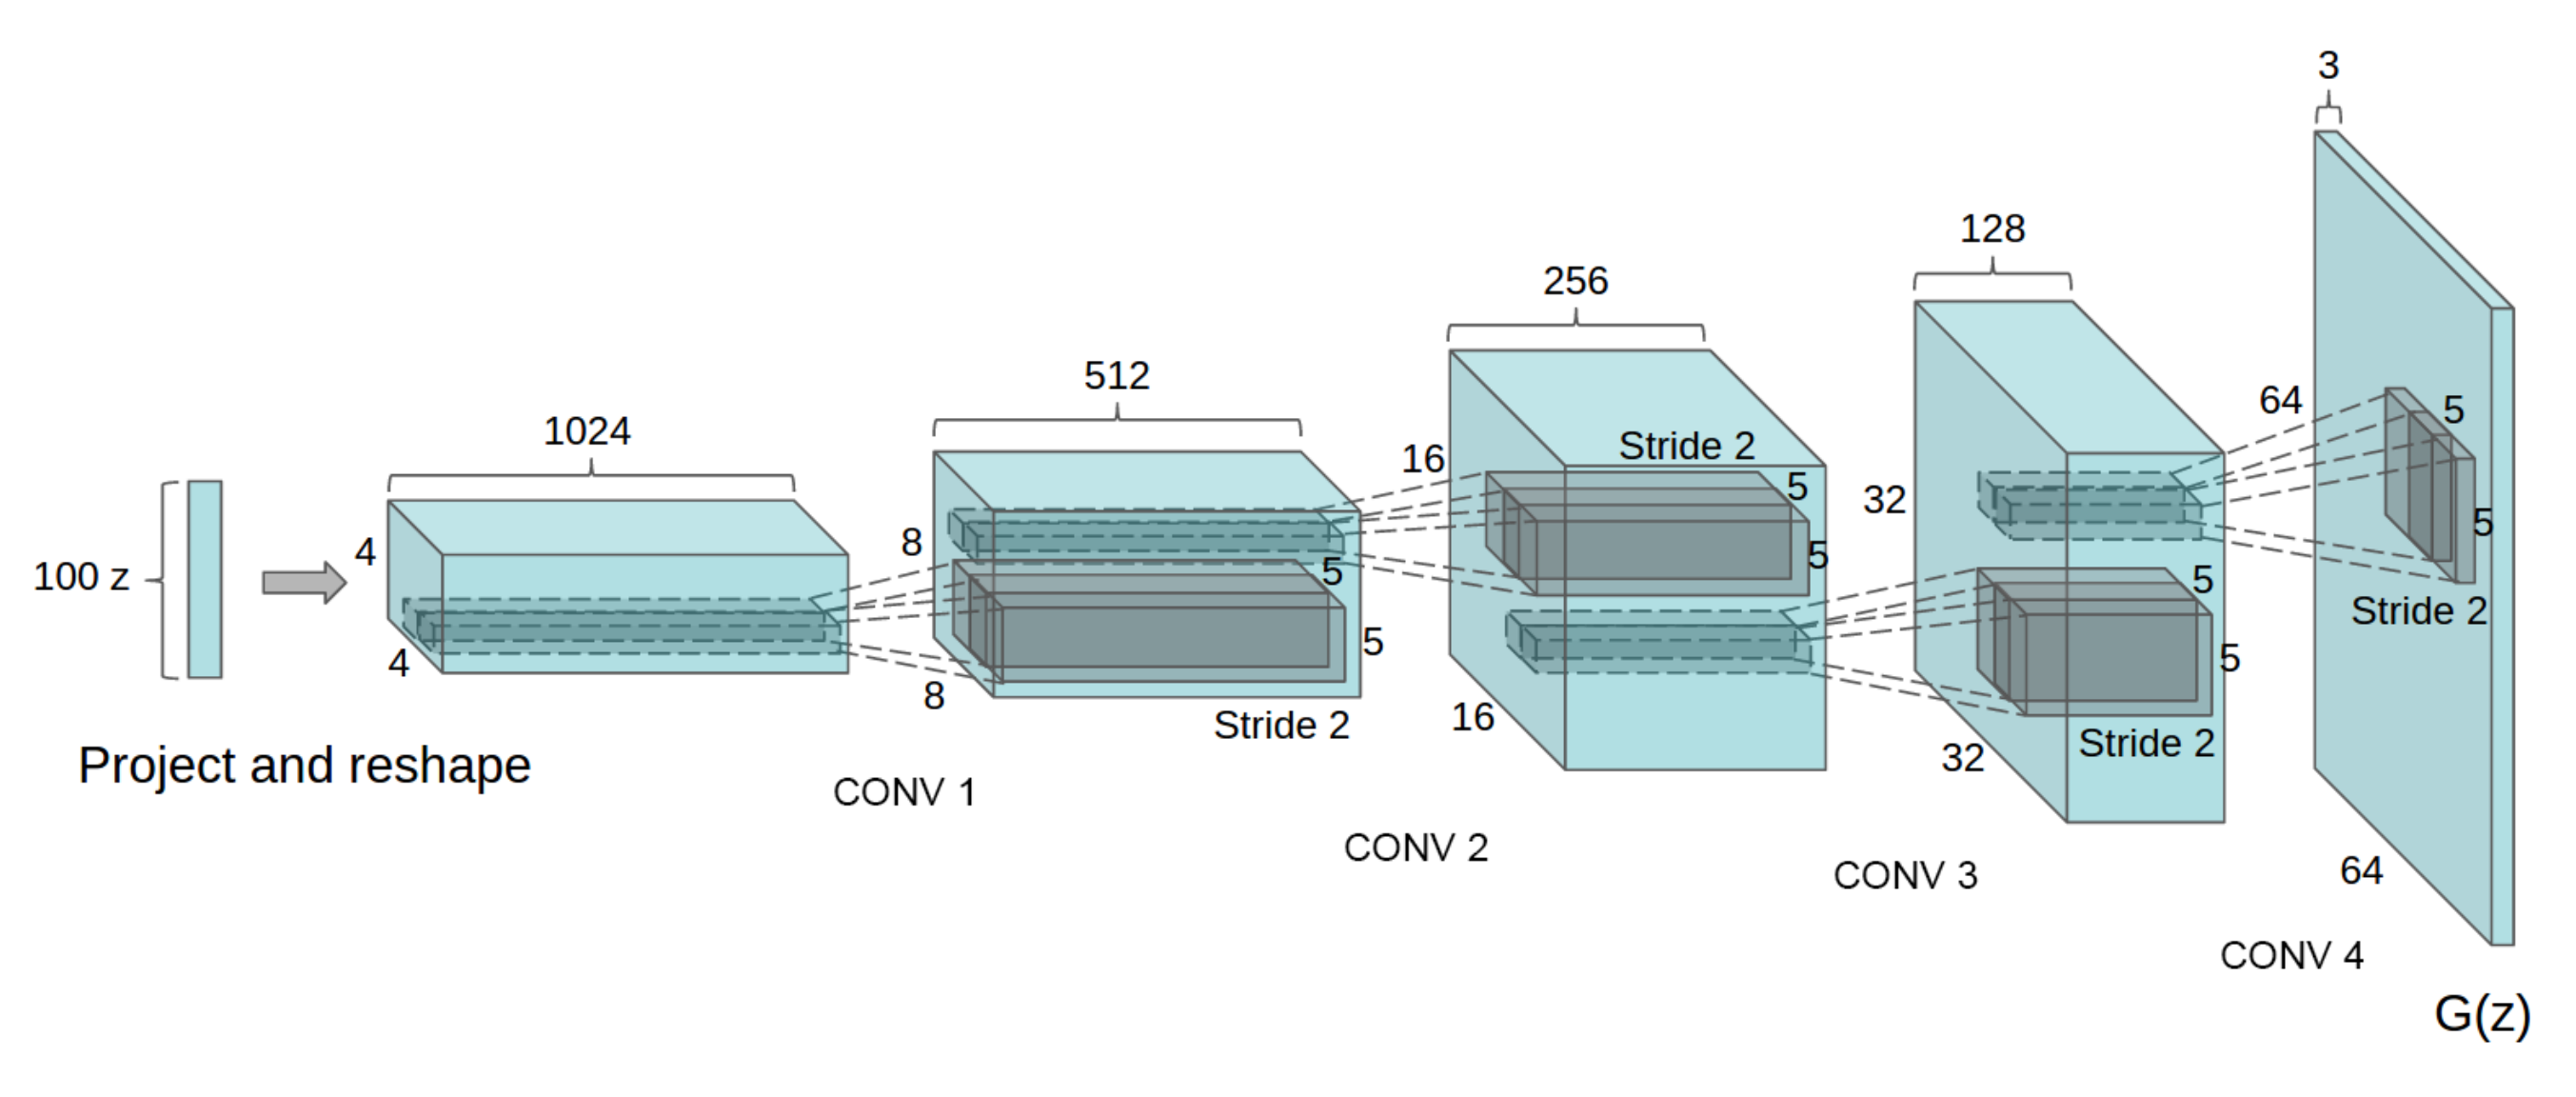

We will use :
- Convolutions without any pooling layers
- Batchnorm in both the generator and the discriminator
- We won't use fully connected hidden layers
- ReLU activation in the generator for all layers except for the output, which uses a Tanh activation.
- LeakyReLU activation in the discriminator for all layers except for the output, which does not use an activation

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision.datasets import MNIST
from torchvision.transforms import transforms


### Generator

We will build a generator using 4 layers (3 hidden layers + 1 output layer). 



In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim= 10, im_chan= 1, hidden_dim= 64):
        super().__init__()
        # Build the neural network
        self.gen = nn.Sequential(
            self.make_gen_block(z_dim, hidden_dim * 4),  # kernel_size = 3, stride= 2, final_layer = false
            self.make_gen_block(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=1), # kernel_size = 4, stride = 1, final_layer = false
            self.make_gen_block(hidden_dim * 2, hidden_dim),    # kernel_size = 3, stride = 2, final_layer= false
            self.make_gen_block(hidden_dim, im_chan, kernel_size=4, final_layer=True) # kernel_size = 4, stride= 2, final_layer = true
        )
        
    # la fonction make gen block pour créer un block du générateur
    def make_gen_block(self, input_channels, output_channels, kernel_size= 3, stride= 2, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace= True) # inplace = True : avec ou sans cela donne les memes résultats, mais avec inplace= True onconsomme moins de VRAM!
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.Tanh()
            )
            
    
    # La fonction unsqueeze_noise
    def unsqueeze_noise(self, noise):
        return noise.view(len(noise), self.z_dim, 1, 1)
    
            
    # la fonction forward
    def forward(self, noise):
        x = self.unsqueeze_noise(noise)
        return self.gen(x)
    

# -------------------------------------------------------------------------------------------    
# la fonction pour créer le bruit
def get_noise(n_samples, z_dim, device= 'cpu'):
    return torch.randn(n_samples, z_dim, device)

### Descriminator

We will create 3 layers for the descriminator neural network

In [ ]:
class Descrminator(nn.Module):
    def __init__(self, im_chan= 1, hidden_dim = 16):
        super().__init__()
        self.disc = nn.Sequential(
            self.make_disc_block(im_chan, hidden_dim),
            self.make_disc_block(hidden_dim, hidden_dim* 2),
            self.make_disc_block(hidden_dim *2, 1, final_layer= True)
        )

    def make_disc_block(self, input_channels, output_channels, kernel_size= 4, stride= 2, final_layer= False):
        # For DCGAN we use this architecture
        if not final_layer:
            
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(negative_slope= 0.2) 
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride)            )
            
        
        
        # For SN-DCGAN we use this architecture 
        # we only replace Conv2d(....) with spectral_norm(conv2d(....)) 
        """if not final_layer:
            return nn.Sequential(
                nn.utils.spectral_norm(nn.Conv2d(input_channels, output_channels, kernel_size, stride)),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace=True),
            )
        else: # Final Layer
            return nn.Sequential(
                nn.utils.spectral_norm(nn.Conv2d(input_channels, output_channels, kernel_size, stride)),
            )""" 
    def forward(self, image):
        disc_pred = self.disc(image)
        return disc_pred.view(len(disc_pred), -1)
            

In [ ]:
criterion = nn.BCEWithLogitsLoss()
z_dim = 64
display_step = 500
batch_size = 128
lr= 0.0002

beta_1 = 0.5
beta_2 = 0.999
device= 'cpu'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataloader = DataLoader(
    MNIST('.', download= False, transform= transform ),
    batch_size= batch_size, 
    shuffle= True
)

In [ ]:
gen = Generator(z_dim).to(device)
disc = Descrminator().to(device)


gen_opt = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta_1, beta_2))
disc_opt = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta_1, beta_2))



def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)
gen = gen.apply(weights_init)
disc = disc.apply(weights_init)



### Explication sur la fonction "weight_init":

Par défaut, quand on crée un réseau dans PyTorch, il remplit les neurones avec des valeurs aléatoires standards. Les auteurs du papier original DCGAN ont découvert que pour les GANs convolutifs, les valeurs par défaut de PyTorch rendaient souvent le modèle instable dès le départ.

Ils ont prouvé qu'un GAN convolutif avait beaucoup plus de chances de réussir si tous les poids suivaient une loi normale très précise : une moyenne de 0.0 et un écart-type de 0.02 (torch.nn.init.normal_(m.weight, 0.0, 0.02))

In [16]:
# La boucle d'entrainement

